# 08 · Додаткові сабмішни: ансамбль прогонів, DINOv2, промпти SigLIP2

Цей ноутбук — **поза фінальним рішенням** (`final_submission.ipynb` залишається тим, що здається).
Мета — використати ще 3 сабмішни на незалежні ідеї, не підганяючи їх під public LB:

| | Ідея | Чому може допомогти |
|---|---|---|
| A | ансамбль двох прогонів конвеєра (07 і `final_submission`) | менша дисперсія (різні DeBERTa / сіди) |
| B | третій енкодер фото — **DINOv2-L** (self-supervised, без тексту) | «бачить» фото інакше, ніж CLIP/SigLIP → менш корельовані помилки |
| C | промпти zero-shot, підібрані під SigLIP2 | зараз «порода» в SigLIP2 майже без сигналу (ρ 0.04 проти 0.28 у CLIP) |

**Правило відбору** (за **чесною** OOF-оцінкою — пороги з інших фолдів):
- B і C йдуть у сабмішн, лише якщо покращують її хоча б на ~0.005 (менше — шум між сідами);
- A — про зменшення дисперсії, а не приріст, тож достатньо «не гірше» (допуск 0.002).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy.stats import spearmanr

from src.config import ID_COL, TARGET_COL, PROCESSED_DIR
from src.utils import seed_everything, qwk, OptimizedRounder, write_submission
from src.pipeline import (FinalConfig, LEVEL1_NAMES, prepare_data, text_features, clip_features,
                          siglip_features, ridge_models, deberta_model, attention_head_model,
                          level2_stack, oof_qwk)

cfg = FinalConfig(use_cache=True)   # reuses data/final_cache from final_submission.ipynb
seed_everything(cfg.seed)
sns.set_theme(style="whitegrid")

def honest_qwk(oof: np.ndarray) -> float:
    """QWK with thresholds fit on the other folds (no threshold optimism)."""
    pred = np.zeros(n_tr)
    for f in np.unique(folds):
        pred[folds == f] = OptimizedRounder().fit(oof[folds != f], y[folds != f]).predict(oof[folds == f])
    return qwk(y, pred)

def summarize(name: str, oof: np.ndarray) -> dict:
    return {"варіант": name, "OOF QWK": oof_qwk(y, oof), "чесна OOF QWK": honest_qwk(oof)}

## 1. Відтворюємо фінальний стек із кешу

Ті самі функції `src/pipeline.py`, що й у `final_submission` (ембедінги й DeBERTa — з кешу, кілька хвилин).

In [2]:
train, test, img_index = prepare_data(cfg)
y, folds, n_tr = train[TARGET_COL].to_numpy(float), train["fold"].to_numpy(), len(train)

text_f = text_features(train, test, cfg)
clip_f, clip_embs = clip_features(img_index, train, test, cfg)
siglip_f, siglip_embs = siglip_features(img_index, train, test, cfg)
level1 = ridge_models(train, test, clip_embs, siglip_embs, cfg)
level1["text_deberta"] = deberta_model(train, test, cfg)
level1["head_img"] = attention_head_model(img_index, train, test, clip_embs, siglip_embs, cfg)
level1 = level1[list(LEVEL1_NAMES)]

n_photos = pd.concat([train[["n_photos"]], test[["n_photos"]]], ignore_index=True)
X_final = pd.concat([n_photos, text_f, clip_f, siglip_f, level1], axis=1)
final = level2_stack(X_final, train, cfg)
results = [summarize("фінальний стек (final_submission)", final["oof"])]
pd.DataFrame(results).round(4)

C:\Users\pbori\Documents\Courses\Neoversity\DeepL\neoversity-dl-cv-final\src\images.py:253: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  zs = zero_shot_features(img_emb, model, tokenizer, device, logit_scale=float(model.logit_scale.exp()))


,варіант,OOF QWK,чесна OOF QWK
0,фінальний стек (final_submission),0.6243,0.6194


## 2. Сабмішн A: ансамбль двох прогонів

У 07 і у `final_submission` — той самий конвеєр, але різні прогони DeBERTa (GPU-недетермінованість) і,
отже, різні стеки. Усереднюємо неперервні передбачення (OOF — на тих самих фолдах) і підбираємо пороги заново.

In [3]:
oof_07, test_07 = np.load(PROCESSED_DIR / "oof_final.npy"), np.load(PROCESSED_DIR / "test_final.npy")
print("corr OOF 07 vs final:", np.corrcoef(oof_07, final["oof"])[0, 1].round(4))

oof_A = (oof_07 + final["oof"]) / 2
test_A = (test_07 + final["test"]) / 2
results += [summarize("стек 07", oof_07), summarize("A: ансамбль 07 + final", oof_A)]
pd.DataFrame(results).round(4)

corr OOF 07 vs final: 0.9995


,варіант,OOF QWK,чесна OOF QWK
0,фінальний стек (final_submission),0.6243,0.6194
1,стек 07,0.6210,0.6124
2,A: ансамбль 07 + final,0.6195,0.6145


In [4]:
gain_A = honest_qwk(oof_A) - honest_qwk(final["oof"])
print(f"honest gain vs final: {gain_A:+.4f}")
if gain_A >= -0.002:
    rounder_A = OptimizedRounder().fit(oof_A, y)
    write_submission(test[ID_COL], rounder_A.predict(test_A), "08a_ensemble_runs")
else:
    print("ensemble is worse than the final stack — not worth a submission")

honest gain vs final: -0.0049
ensemble is worse than the final stack — not worth a submission


## 3. Сабмішн B: третій енкодер фото — DINOv2-L

DINOv2 (Meta, 2023) навчений **без тексту** (self-supervised) — ознаки фото в нього інші, ніж у CLIP/SigLIP2.
Для кожного фото: [CLS ‖ середнє патч-токенів] (2 048 вимірів). Далі — як для інших енкодерів:
Ridge на ембедінгах тварини, OOF kNN-target, і DINOv2 додається в attention-голову.

In [5]:
from src.features import knn_target_features
from src.images import pet_embeddings
from src.models import ridge_oof
from src.image_head import HeadConfig, build_bags, run_head_cv

dino_emb = np.load(PROCESSED_DIR / "dino_img_emb.npy")        # computed by src.images.extract_dino_embeddings
assert len(dino_emb) == len(img_index)
pet_ids, d_first, d_mean = pet_embeddings(img_index, dino_emb)
pos = pd.Series(np.arange(len(pet_ids)), index=pet_ids)
tr_pos, te_pos = pos[train[ID_COL]].to_numpy(), pos[test[ID_COL]].to_numpy()
D = np.vstack([np.hstack([d_mean[tr_pos], d_first[tr_pos]]), np.hstack([d_mean[te_pos], d_first[te_pos]])])

rows = []
for alpha in (3.0, 10.0, 30.0):
    o, t = ridge_oof(D[:n_tr], D[n_tr:], y, folds, alpha=alpha)
    rows.append({"alpha": alpha, "OOF QWK": oof_qwk(y, o), "oof": o, "test": t})
best = max(rows, key=lambda r: r["OOF QWK"])
ridge_dino = np.r_[best["oof"], best["test"]]
display(pd.DataFrame(rows)[["alpha", "OOF QWK"]].round(4))
print("corr Ridge DINOv2 vs Ridge SigLIP2:", np.corrcoef(best["oof"], level1["ridge_siglip_img"][:n_tr])[0, 1].round(3),
      "  vs Ridge CLIP:", np.corrcoef(best["oof"], level1["ridge_clip_img"][:n_tr])[0, 1].round(3))

knn_tr, knn_te = knn_target_features(d_mean[tr_pos], d_mean[te_pos], y, folds, prefix="dino")
dino_knn = pd.concat([knn_tr, knn_te], ignore_index=True)

,alpha,OOF QWK
0,3.0,0.5542
1,10.0,0.5633
2,30.0,0.5222


corr Ridge DINOv2 vs Ridge SigLIP2: 0.887   vs Ridge CLIP: 0.889


In [6]:
# Attention head over CLIP ⊕ SigLIP2 ⊕ DINOv2 photo embeddings (same config as 06, 5 seeds)
embs3 = [clip_embs["img_emb"], siglip_embs["img_emb"], dino_emb]
bags_tr, mask_tr = build_bags(img_index, embs3, train[ID_COL], 12)
bags_te, mask_te = build_bags(img_index, embs3, test[ID_COL], 12)
head3_oof, head3_te = np.zeros(n_tr), np.zeros(len(test))
for s in range(cfg.head_seeds):
    r = run_head_cv(bags_tr, mask_tr, bags_te, mask_te, y, folds, HeadConfig(epochs=7, seed=cfg.seed + s),
                    device=cfg.device, verbose=False)
    head3_oof += r["oof"] / cfg.head_seeds; head3_te += r["test"] / cfg.head_seeds
del bags_tr, bags_te; torch.cuda.empty_cache()
print(f"head CLIP+SigLIP2: {oof_qwk(y, level1['head_img'].to_numpy()[:n_tr]):.4f}   "
      f"head CLIP+SigLIP2+DINOv2: {oof_qwk(y, head3_oof):.4f}")
head3 = np.r_[head3_oof, head3_te]

head CLIP+SigLIP2: 0.6112   head CLIP+SigLIP2+DINOv2: 0.6052


In [7]:
variants_B = {
    "B1: + Ridge DINOv2": X_final.assign(ridge_dino_img=ridge_dino),
    "B2: + Ridge DINOv2 + kNN DINOv2": pd.concat([X_final.assign(ridge_dino_img=ridge_dino), dino_knn], axis=1),
    "B3: B2 + голова з DINOv2 (замість старої)": pd.concat(
        [X_final.assign(ridge_dino_img=ridge_dino, head_img=head3), dino_knn], axis=1),
}
stacks_B = {}
for name, X in variants_B.items():
    stacks_B[name] = level2_stack(X, train, cfg)
    results.append(summarize(name, stacks_B[name]["oof"]))
pd.DataFrame(results).round(4)

,варіант,OOF QWK,чесна OOF QWK
0,фінальний стек (final_submission),0.6243,0.6194
1,стек 07,0.6210,0.6124
2,A: ансамбль 07 + final,0.6195,0.6145
3,B1: + Ridge DINOv2,0.6227,0.6185
4,B2: + Ridge DINOv2 + kNN DINOv2,0.6256,0.6121
5,B3: B2 + голова з DINOv2 (замість старої),0.6237,0.6171


In [8]:
# Pick the B variant with the best honest OOF; submit it only if it beats the final stack by >= 0.005
best_B = max(stacks_B, key=lambda k: honest_qwk(stacks_B[k]["oof"]))
gain_B = honest_qwk(stacks_B[best_B]["oof"]) - honest_qwk(final["oof"])
print(f"best: {best_B}   honest gain vs final: {gain_B:+.4f}")
if gain_B >= 0.005:
    sB = stacks_B[best_B]
    write_submission(test[ID_COL], sB["rounder"].predict(sB["test"]), "08b_dinov2")
else:
    print("gain below 0.005 — not worth a submission")

best: B1: + Ridge DINOv2   honest gain vs final: -0.0008
gain below 0.005 — not worth a submission


## 4. Варіант C: промпти zero-shot під SigLIP2

SigLIP навчений на коротких альт-текстах, тож замість «a photo of a purebred pedigree pet» даємо конкретні
назви («Persian cat», «husky», «mixed-breed street dog»). Ембедінги фото вже в кеші — перераховуються
лише текстові ембедінги промптів.

In [9]:
from src.images import load_clip, zero_shot_features, aggregate_per_pet

SIGLIP_PROMPTS = {
    "breed": {
        "pure": ["Persian cat", "Siamese cat", "British Shorthair cat", "Maine Coon cat", "Bengal cat",
                 "husky", "poodle", "shih tzu", "golden retriever", "labrador retriever", "pomeranian",
                 "german shepherd", "rottweiler", "beagle", "chihuahua", "dachshund", "schnauzer", "corgi"],
        "mixed": ["mixed-breed street dog", "stray cat", "domestic shorthair cat", "tabby street cat",
                  "mongrel dog", "local village dog"],
    },
    "age": {
        "baby": ["newborn kitten", "newborn puppy"], "young": ["kitten", "puppy"],
        "adult": ["adult cat", "adult dog"], "old": ["old cat", "old dog"],
    },
    "fur": {"short": ["short-haired pet"], "long": ["long-haired fluffy pet"]},
    "count": {"one": ["one animal"], "many": ["litter of kittens", "litter of puppies", "group of animals"]},
}

model, _, tokenizer = load_clip(cfg.siglip_model, cfg.siglip_pretrained, cfg.device)
zs_new = zero_shot_features(siglip_embs["img_emb"], model, tokenizer, cfg.device, prompts=SIGLIP_PROMPTS,
                            logit_scale=float(model.logit_scale.exp()))
del model; torch.cuda.empty_cache()
pet_zs_new = aggregate_per_pet(img_index, zs_new, aggs=("first", "mean", "max"))
zs_new_f = pd.concat([train[[ID_COL]], test[[ID_COL]]], ignore_index=True).merge(pet_zs_new, on=ID_COL, how="left")
zs_new_f = zs_new_f.drop(columns=ID_COL).add_prefix("siglip2p_")

old = siglip_f[[c for c in siglip_f.columns if any(c.startswith(f"siglip_zs_{g}_") for g in SIGLIP_PROMPTS)]]
corr = lambda df: df[:n_tr].apply(lambda c: abs(spearmanr(c, y)[0]))
cmp = pd.DataFrame({"старі промпти": corr(old).rename(lambda c: c.removeprefix("siglip_zs_")),
                    "нові промпти": corr(zs_new_f).rename(lambda c: c.removeprefix("siglip2p_zs_"))})
cmp.sort_values("нові промпти", ascending=False).head(12).round(3)

,старі промпти,нові промпти
age_adult_mean,0.325,0.357
age_baby_mean,0.291,0.350
age_adult_first,0.323,0.350
breed_pure_mean,0.038,0.342
breed_mixed_mean,0.038,0.342
age_baby_first,0.286,0.336
age_adult_max,0.309,0.334
age_baby_max,0.280,0.331
breed_mixed_first,0.025,0.326
breed_pure_first,0.025,0.326


In [10]:
X_C = pd.concat([X_final, zs_new_f], axis=1)
stack_C = level2_stack(X_C, train, cfg)
results.append(summarize("C: + нові промпти SigLIP2", stack_C["oof"]))

X_BC = pd.concat([variants_B[best_B], zs_new_f], axis=1)
stack_BC = level2_stack(X_BC, train, cfg)
results.append(summarize(f"B+C: {best_B.split(':')[0]} + нові промпти", stack_BC["oof"]))
pd.DataFrame(results).round(4)

,варіант,OOF QWK,чесна OOF QWK
0,фінальний стек (final_submission),0.6243,0.6194
1,стек 07,0.6210,0.6124
2,A: ансамбль 07 + final,0.6195,0.6145
3,B1: + Ridge DINOv2,0.6227,0.6185
4,B2: + Ridge DINOv2 + kNN DINOv2,0.6256,0.6121
5,B3: B2 + голова з DINOv2 (замість старої),0.6237,0.6171
6,C: + нові промпти SigLIP2,0.6203,0.6150
7,B+C: B1 + нові промпти,0.6205,0.6148


In [11]:
# Third submission: the best of C / B+C by honest OOF, if it beats the final stack by >= 0.005
cands = {"08c_siglip_prompts": stack_C, "08c_dinov2_siglip_prompts": stack_BC}
name_C = max(cands, key=lambda k: honest_qwk(cands[k]["oof"]))
gain_C = honest_qwk(cands[name_C]["oof"]) - honest_qwk(final["oof"])
print(f"best: {name_C}   honest gain vs final: {gain_C:+.4f}")
if gain_C >= 0.005:
    write_submission(test[ID_COL], cands[name_C]["rounder"].predict(cands[name_C]["test"]), name_C)
else:
    print("gain below 0.005 — not worth a submission")

best: 08c_siglip_prompts   honest gain vs final: -0.0044
gain below 0.005 — not worth a submission


## 5. Підсумок

In [12]:
summary = pd.DataFrame(results).round(4)
summary["Δ чесна vs final"] = (summary["чесна OOF QWK"] - summary.loc[0, "чесна OOF QWK"]).round(4)
summary

,варіант,OOF QWK,чесна OOF QWK,Δ чесна vs final
0,фінальний стек (final_submission),0.6243,0.6194,0.0000
1,стек 07,0.6210,0.6124,-0.0070
2,A: ансамбль 07 + final,0.6195,0.6145,-0.0049
3,B1: + Ridge DINOv2,0.6227,0.6185,-0.0009
4,B2: + Ridge DINOv2 + kNN DINOv2,0.6256,0.6121,-0.0073
5,B3: B2 + голова з DINOv2 (замість старої),0.6237,0.6171,-0.0023
6,C: + нові промпти SigLIP2,0.6203,0.6150,-0.0044
7,B+C: B1 + нові промпти,0.6205,0.6148,-0.0046


## 6. Adversarial validation: чи відрізняється test від train?

На public LB у нас (і в інших учасників) QWK ≈ 0.80, а на крос-валідації ≈ 0.62. Щоб зрозуміти, чи test
«інший» за вхідними даними, вчимо класифікатор відрізняти рядки test від train за тими самими ознаками,
що використовує модель (текст, CLIP, SigLIP2). Target-залежні ознаки (kNN-target) виключаємо — вони
рахуються для train і test по-різному за побудовою.

- **ROC AUC ≈ 0.5** → класифікатор не бачить різниці: test — та сама вибірка, що й train (за входами);
- **AUC помітно > 0.5** → test відрізняється, а найважливіші ознаки класифікатора показують, чим саме.

In [2]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

meta_tr = pd.read_parquet(PROCESSED_DIR / "train_meta.parquet")
meta_te = pd.read_parquet(PROCESSED_DIR / "test_meta.parquet")

def load_feats(name: str) -> pd.DataFrame:
    return pd.concat([pd.read_parquet(PROCESSED_DIR / f"{name}_{s}.parquet") for s in ("train", "test")],
                     ignore_index=True).drop(columns=ID_COL)

X_adv = pd.concat([pd.concat([meta_tr[["n_photos"]], meta_te[["n_photos"]]], ignore_index=True),
                   load_feats("text_feats"), load_feats("img_feats"), load_feats("img_feats_siglip")], axis=1)
X_adv = X_adv.drop(columns=[c for c in X_adv.columns if "knn" in c or "nn1" in c])
is_test = np.r_[np.zeros(len(meta_tr)), np.ones(len(meta_te))]

p_adv, gain = np.zeros(len(X_adv)), 0
for tr_i, va_i in StratifiedKFold(5, shuffle=True, random_state=0).split(X_adv, is_test):
    clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=31, verbose=-1)
    clf.fit(X_adv.iloc[tr_i], is_test[tr_i])
    p_adv[va_i] = clf.predict_proba(X_adv.iloc[va_i])[:, 1]
    gain = gain + clf.booster_.feature_importance("gain")

print(f"adversarial ROC AUC: {roc_auc_score(is_test, p_adv):.4f}   ({X_adv.shape[1]} features)")
pd.Series(gain, index=X_adv.columns).sort_values(ascending=False).head(10).round(0).to_frame("gain")

adversarial ROC AUC: 0.5324   (234 features)


,gain
siglip_zs_health_sick_max,3543.0
zs_human_no_max,3183.0
contrast_max,3059.0
brightness_max,3027.0
zs_breed_mixed_max,2990.0
desc_upper_ratio,2939.0
brightness_mean,2782.0
zs_scene_cage_max,2770.0
clip_txt_img_first,2758.0
contrast_mean,2721.0


,train,test,"різниця, %"
n_photos,4.427,4.959,12.004
desc_len,364.185,372.559,2.300
desc_words,67.442,69.315,2.777
desc_non_ascii,0.005,0.006,7.662
age_months,8.526,7.691,-9.791
img_kb_mean,27.763,28.009,0.888
zs_type_cat_mean,0.434,0.430,-0.911
zs_age_baby_mean,0.069,0.065,-5.296
zs_age_adult_mean,0.260,0.262,0.813
zs_breed_pure_mean,0.072,0.068,-5.492


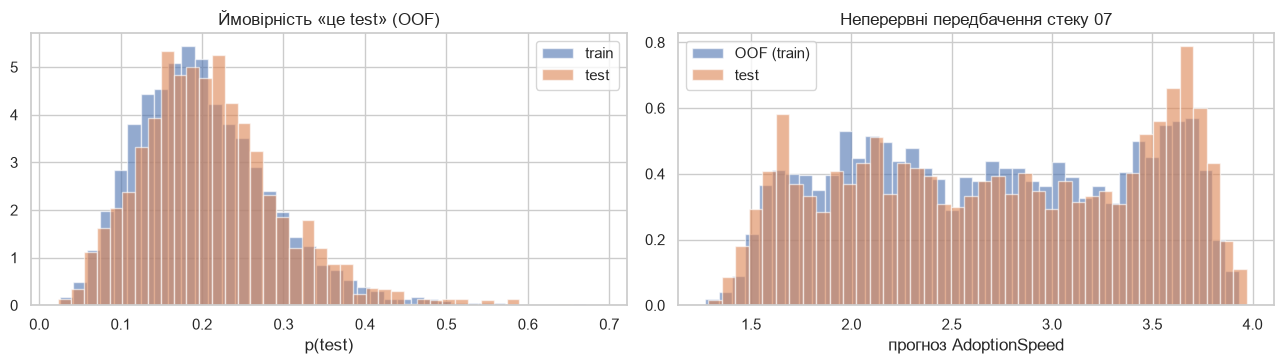

In [3]:
# Mean of key features: train vs test
key = ["n_photos", "desc_len", "desc_words", "desc_non_ascii", "age_months", "img_kb_mean",
       "zs_type_cat_mean", "zs_age_baby_mean", "zs_age_adult_mean", "zs_breed_pure_mean", "txt_dup_size"]
n = len(meta_tr)
cmp_adv = pd.DataFrame({"train": X_adv[key][:n].mean(), "test": X_adv[key][n:].mean()})
cmp_adv["різниця, %"] = (cmp_adv["test"] / cmp_adv["train"] - 1) * 100
display(cmp_adv.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(p_adv[:n], bins=40, alpha=0.6, density=True, label="train")
axes[0].hist(p_adv[n:], bins=40, alpha=0.6, density=True, label="test")
axes[0].set(title="Ймовірність «це test» (OOF)", xlabel="p(test)"); axes[0].legend()
# The model's continuous predictions: OOF on train vs test
oof_f, test_f = np.load(PROCESSED_DIR / "oof_final.npy"), np.load(PROCESSED_DIR / "test_final.npy")
axes[1].hist(oof_f, bins=40, alpha=0.6, density=True, label="OOF (train)")
axes[1].hist(test_f, bins=40, alpha=0.6, density=True, label="test")
axes[1].set(title="Неперервні передбачення стеку 07", xlabel="прогноз AdoptionSpeed"); axes[1].legend()
plt.tight_layout();

**Результат.** ROC AUC ≈ 0.53 — класифікатор практично не відрізняє test від train: розподіли довжини й мови
описів, типу й віку тварин за фото, якості фото, частоти майже-дублікатів збігаються. Єдина помітна відмінність —
у test трохи більше фото на тварину (≈ 5.0 проти 4.4). Розподіл передбачень моделі на test теж майже такий самий,
як OOF на train.

Отже, **за вхідними даними test — та сама вибірка**, і розрив CV ≈ 0.62 vs public ≈ 0.80 (однаковий у різних
учасників) не пояснюється зсувом ознак. Лишаються два пояснення, які без міток test перевірити неможливо:
(1) мітки test сформовані / оброблені інакше, ніж у train (інший розподіл класів робить QWK вищим за тієї ж
якості ранжування); (2) public-оцінка рахується на малій частці test. Питання про формування test передано
організаторам курсу.

## Висновки

**Жоден варіант не пройшов поріг** — фінальний стек (`final_submission`, чесна OOF 0.6194) лишається найкращим,
нових сабмішнів не створено. Усі відмінності — у межах шуму (±0.005).

- **A · ансамбль прогонів 07 + final:** чесна 0.6145 (−0.005). Прогони майже ідентичні (corr OOF 0.9995),
  тож усереднення нічого не додає, а прогін 07 був трохи слабшим (0.6124) і тягне ансамбль униз.
- **B · DINOv2-L:** Ridge на ембедінгах 0.563 — слабше за CLIP (0.587) і SigLIP2 (0.600) і корелює з ними на 0.89:
  «інший погляд» на фото виявився не таким уже й іншим для цієї задачі. У стеку: −0.001 … −0.007;
  attention-голова з DINOv2 гірша (0.605 проти 0.611).
- **C · промпти під SigLIP2:** ознаки справді стали набагато кращими — «порода» |ρ| 0.04 → 0.34, вік 0.29 → 0.35.
  Але в стеку −0.004: ту саму інформацію вже дають zero-shot CLIP і Ridge на ембедінгах.
- **Загальний висновок:** рішення вийшло на плато ~0.62 OOF. Подальші покращення фото-ознак дублюють уже наявний
  сигнал; для помітного приросту потрібна якісно нова інформація (напр. fine-tuning енкодера фото),
  а не ще один заморожений енкодер чи нові ознаки з того самого.